## Ejercicio 2: Agente de triaje para mesa de ayuda (Soporte)

### Ficha PEAS
| Componente | Descripción |
| :--- | :--- |
| **Percepción (S)** | `rol_usuario` (admin, vip, estándar), `criticidad_sistema` (alta, media, baja), `descripcion_ticket` |
| **Acciones (A)** | Asignar Prioridad Crítica (P1), Alta (P2), Media (P3), Baja (P4) |
| **Entorno (E)** | Sistema ITSM de soporte e infraestructura de TI de la empresa |
| **Objetivo** | Minimizar el tiempo de inactividad de los sistemas resolviendo incidencias graves primero |
| **Medida de desempeño (P)** | Cumplimiento del SLA y tiempo promedio de resolución de incidencias |

### Justificación de las reglas
Un usuario Admin o VIP que reporta una falla en un sistema de criticidad Alta requiere atención prioritaria inmediata (P1) para evitar impacto operativo masivo. Los usuarios estándar con incidencias de baja criticidad se clasifican en P4 para no saturar al equipo de soporte.

In [2]:
def agente_soporte(rol_usuario, criticidad_sistema, descripcion_ticket):
    rol = rol_usuario.lower()
    criticidad = criticidad_sistema.lower()

    if rol in ["admin", "vip"] and criticidad == "alta":
        return (
            "P1 - Crítica",
            "Impacto crítico en infraestructura por usuario clave.",
        )
    elif rol in ["admin", "vip"] or criticidad == "alta":
        return (
            "P2 - Alta",
            "Elevada prioridad por perfil de usuario o criticidad del sistema.",
        )
    elif criticidad == "media":
        return (
            "P3 - Media",
            "Incidencia estándar de impacto moderado en el flujo de trabajo.",
        )
    else:
        return (
            "P4 - Baja",
            "Solicitud o incidencia menor sin afectación crítica.",
        )

In [3]:
tickets_prueba = [
    ("admin", "alta", "Caída de BD principal"),
    ("estandar", "alta", "Fallo en facturación"),
    ("vip", "media", "Error en reporte PDF"),
    ("estandar", "baja", "Cambio de mouse"),
    ("vip", "alta", "Servidor correo caído"),
    ("estandar", "media", "Impresora desconfigurada"),
]

print("--- RESULTADOS DE TRIAJE ---")
for r, c, d in tickets_prueba:
    prio, mot = agente_soporte(r, c, d)
    print(f"Ticket [{r.upper()} | Crit: {c.upper()}] -> {prio} | Motivo: {mot}")

--- RESULTADOS DE TRIAJE ---
Ticket [ADMIN | Crit: ALTA] -> P1 - Crítica | Motivo: Impacto crítico en infraestructura por usuario clave.
Ticket [ESTANDAR | Crit: ALTA] -> P2 - Alta | Motivo: Elevada prioridad por perfil de usuario o criticidad del sistema.
Ticket [VIP | Crit: MEDIA] -> P2 - Alta | Motivo: Elevada prioridad por perfil de usuario o criticidad del sistema.
Ticket [ESTANDAR | Crit: BAJA] -> P4 - Baja | Motivo: Solicitud o incidencia menor sin afectación crítica.
Ticket [VIP | Crit: ALTA] -> P1 - Crítica | Motivo: Impacto crítico en infraestructura por usuario clave.
Ticket [ESTANDAR | Crit: MEDIA] -> P3 - Media | Motivo: Incidencia estándar de impacto moderado en el flujo de trabajo.


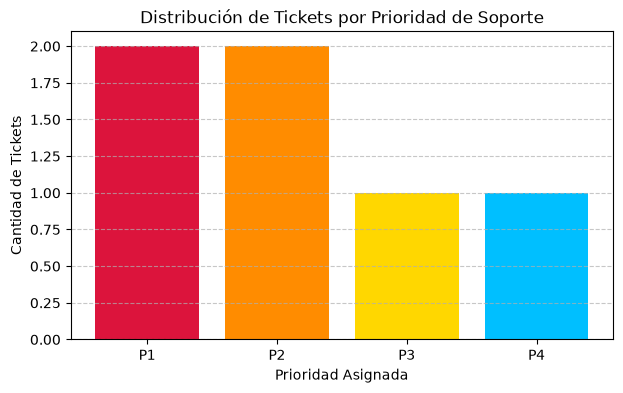

In [4]:
import matplotlib.pyplot as plt

prioridades = [
    agente_soporte(r, c, d)[0].split(" - ")[0] for r, c, d in tickets_prueba
]
conteo = {p: prioridades.count(p) for p in ["P1", "P2", "P3", "P4"]}

plt.figure(figsize=(7, 4))
plt.bar(
    conteo.keys(),
    conteo.values(),
    color=["crimson", "darkorange", "gold", "deepskyblue"],
)
plt.title("Distribución de Tickets por Prioridad de Soporte")
plt.xlabel("Prioridad Asignada")
plt.ylabel("Cantidad de Tickets")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()